In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

import umap.umap_ as UMAP
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.express as px

In [3]:
centers=[[ 2, -6, -6],
         [-1,  9,  4],
         [-8,  7,  2],
         [ 4,  7,  9]]
cluster_std=[1,1,2,3.5]
data_points, centroid = make_blobs(n_samples=500, centers=centers, cluster_std=cluster_std, n_features=3, random_state=42)

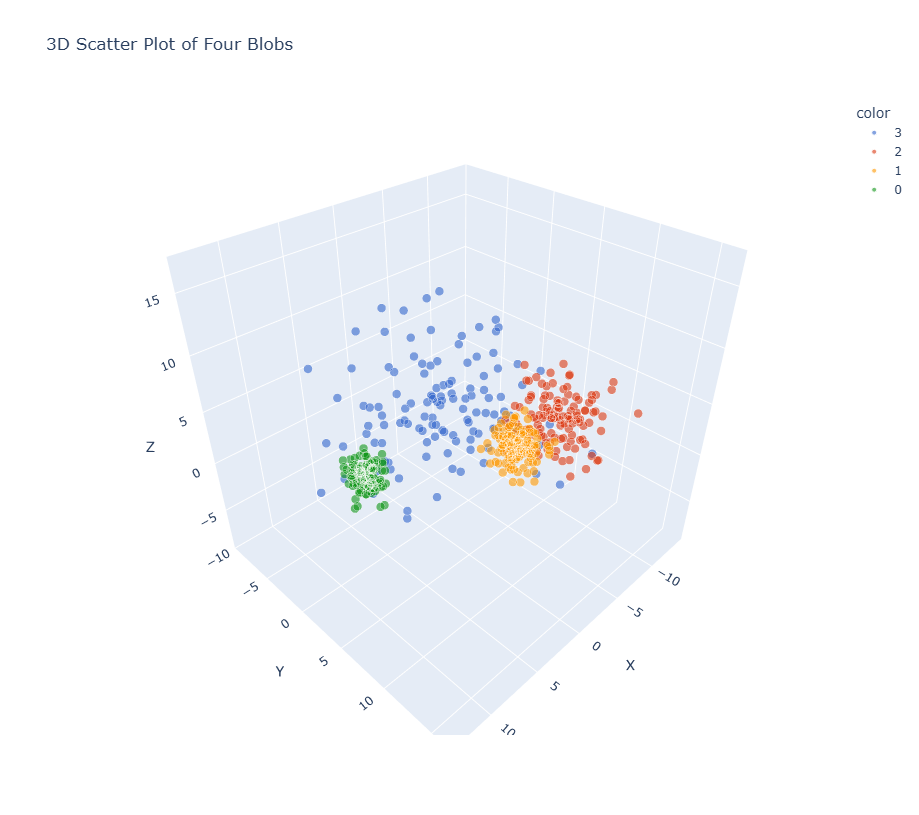

In [18]:
data_f = pd.DataFrame(data_points, columns=["X", "Y", "Z"])

fig = px.scatter_3d(data_f, x="X", y="Y", z="Z", color=centroid.astype(str), opacity=0.6, color_discrete_sequence=px.colors.qualitative.G10, title="3D Scatter Plot of Four Blobs")
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='white')), showlegend=True)
fig.update_layout(coloraxis_showscale=True, width=1000, height=800)
fig.show()

In [19]:
scaler = StandardScaler()
scaled_dp = scaler.fit_transform(data_points)

In [31]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_dp = tsne.fit_transform(scaled_dp)

In [32]:
tsne_dp

array([[ 5.71700001e+00,  1.88091297e+01],
       [-1.63287267e-01, -2.09614754e+01],
       [ 1.06489697e+01,  1.90571632e+01],
       [ 5.72324610e+00, -2.48840847e+01],
       [ 1.03210926e+01, -3.10423493e+00],
       [ 1.01973257e+01, -3.69740844e+00],
       [-3.09184837e+01,  3.57328629e+00],
       [ 1.23489857e+01, -1.51234716e-01],
       [ 3.27813244e+00,  2.62488937e+01],
       [-3.42827110e+01,  1.58695292e+00],
       [ 1.74403648e+01, -4.39676046e-01],
       [ 1.53283710e+01,  5.60634422e+00],
       [-4.00457954e+01,  8.72134399e+00],
       [ 6.77216959e+00,  2.01875210e+01],
       [ 6.09526443e+00, -2.79875336e+01],
       [ 1.67935963e+01,  6.23520708e+00],
       [-3.65712585e+01,  6.88049841e+00],
       [-3.70293732e+01,  5.93541336e+00],
       [ 9.57434893e-01, -3.00872059e+01],
       [ 3.61933255e+00,  2.53786144e+01],
       [ 1.37510910e+01,  2.01941624e+01],
       [-7.91427493e-01, -2.57968845e+01],
       [ 3.67706084e+00, -3.02066708e+01],
       [ 4.

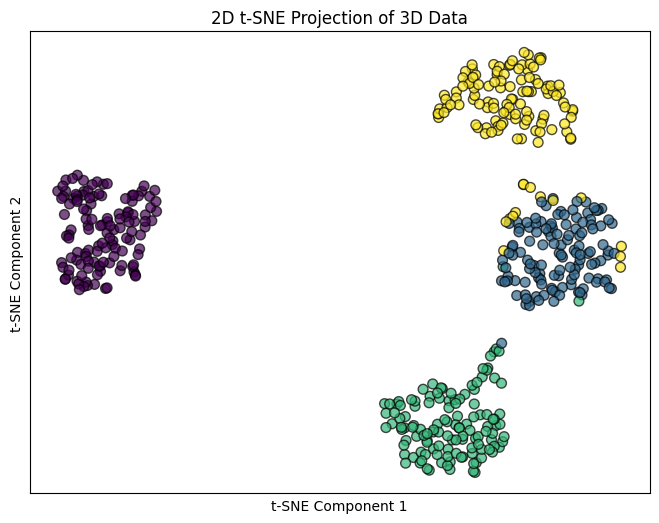

In [34]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.scatter(tsne_dp[:, 0], tsne_dp[:, 1], c=centroid, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax.set_title("2D t-SNE Projection of 3D Data")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

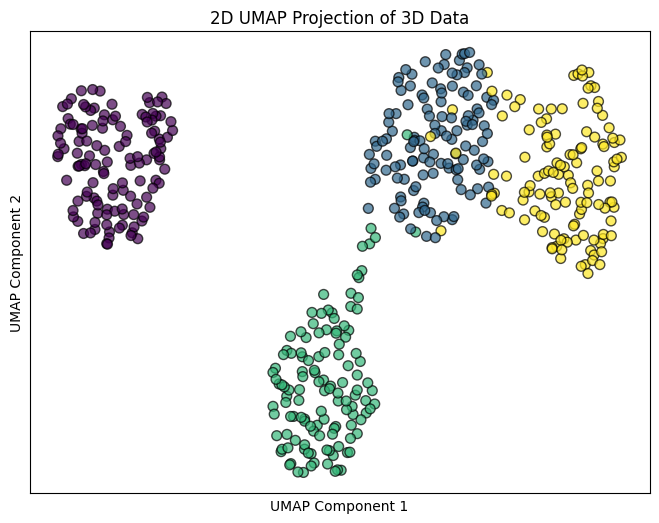

In [47]:
# Apply UMAP to reduce the dimensionality to 2D
umap_model = UMAP.UMAP(n_components=2, random_state=42, min_dist=0.5, spread=1,n_jobs=1)

umap_dp = umap_model.fit_transform(scaled_dp)

# Plot the 2D UMAP projection result 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.scatter(umap_dp[:, 0], umap_dp[:, 1], c=centroid, cmap='viridis', s=50, alpha=0.7, edgecolor='k')

ax.set_title("2D UMAP Projection of 3D Data")
ax.set_xlabel("UMAP Component 1", )
ax.set_ylabel("UMAP Component 2", )
ax.set_xticks([])
ax.set_yticks([])
plt.show()

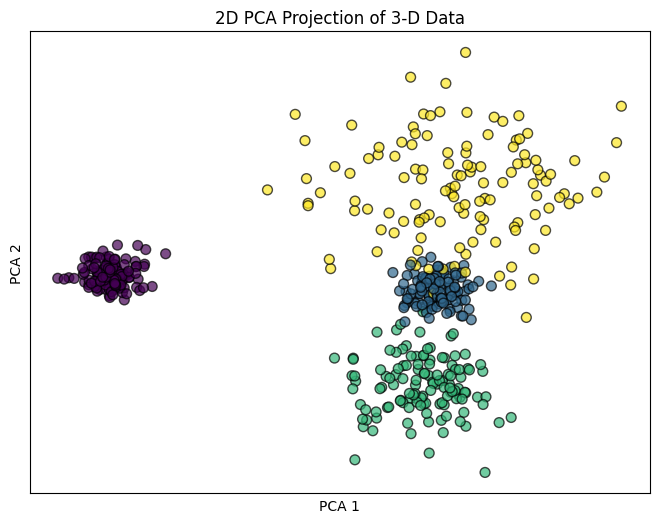

In [48]:
# Apply PCA to reduce the dimensionality to 2D
pca = PCA(n_components=2)
pca_dp = pca.fit_transform(scaled_dp)


fig = plt.figure(figsize=(8, 6))

# Plot the 2D PCA result (right)
ax2 = fig.add_subplot(111)
scatter2 = ax2.scatter(pca_dp[:, 0], pca_dp[:, 1], c=centroid, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax2.set_title("2D PCA Projection of 3-D Data")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_xticks([])
ax2.set_yticks([])
plt.show()